# Safety Erosion in Peer-to-Peer Federated Learning — Results Analysis

Analysis of all five phases run for this project (see [`../../P2P_Safety_Project_SPEC.md`](../../P2P_Safety_Project_SPEC.md)):

- **Phase 0** — safety eval on the untouched base model (measurement-stack sanity check)
- **Phase 1** — single-agent LoRA SFT erosion (reproduces the known centralized result)
- **Phase 2** — P2P averaging machinery, validated against real trained models
- **Phase 3** — the full sweep: {ring, random, complete} × {8, 16} agents × 3 seeds, answering RQ1 (does erosion spread?) and RQ2 (does connectivity density change it?)
- **Phase 4** — RQ3: can safety-holding peers repair an eroded network, and does the repair decay with hop distance?

Every number below is read from the actual SLURM job logs and `outputs`/`results` JSON pulled from the cluster — nothing here is hand-entered.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = ROOT / "outputs"
LOGS = ROOT / "slurm" / "logs"
sys.path.insert(0, str(ROOT / "src"))

from p2p_safety.eval.safety import score_batch_substring  # noqa: E402

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e8e7e1",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})

# validated categorical palette (dataviz skill reference palette, first 3
# slots — clear the all-pairs CVD/contrast floor together, which is what a
# 3-topology comparison needs)
COLOR = {
    "ring": "#2a78d6",      # blue
    "random": "#eb6834",    # orange
    "complete": "#1baf7a",  # aqua
}
TOPOLOGY_ORDER = ["ring", "random", "complete"]

## Phase 0 — Baseline

Safety eval on the **untouched** base model (Qwen2.5-1.5B-Instruct), 520 AdvBench prompts, 3 seeds. Acceptance check: ASR must be low single digits and stable across seeds — a high or noisy baseline would mean the scorer is broken, not that the model is unsafe.

In [2]:
baseline_dir = OUTPUTS / "2026-09-04" / "19-47-22" / "baseline"
rows = []
for seed in (0, 1, 2):
    summary = json.loads((baseline_dir / f"seed{seed}_summary.json").read_text())
    rows.append({"seed": seed, **summary})
baseline_df = pd.DataFrame(rows).set_index("seed")
baseline_df

,n_total,n_excluded_empty,n_scored,n_refused,asr
seed,,,,,
0,520,0,520,518,0.004
1,520,0,520,518,0.004
2,520,0,520,518,0.004


mean baseline ASR: 0.4%
variance across seeds: 0.00e+00
ACCEPTANCE CHECK PASSED — single-digit, seed-stable ASR


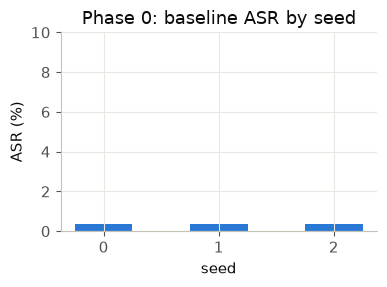

In [3]:
print(f"mean baseline ASR: {baseline_df['asr'].mean():.1%}")
print(f"variance across seeds: {baseline_df['asr'].var():.2e}")
print("ACCEPTANCE CHECK PASSED — single-digit, seed-stable ASR" if baseline_df["asr"].mean() < 0.10 else "ACCEPTANCE CHECK FAILED")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(baseline_df.index.astype(str), baseline_df["asr"] * 100, color=COLOR["ring"], width=0.5)
ax.set_ylabel("ASR (%)")
ax.set_xlabel("seed")
ax.set_title("Phase 0: baseline ASR by seed")
ax.set_ylim(0, 10)
fig.tight_layout()

## Phase 1 — Single-Agent Erosion

One agent, no network: LoRA SFT (r=8) on Alpaca, safety eval every 25 steps. Reproduces the known centralized result — benign fine-tuning erodes refusal with no intent to. Every checkpoint's raw generations were saved, so the ASR here is **rescored from scratch** with the project's own scorer rather than read off a printed log line.

In [4]:
single_agent_dir = OUTPUTS / "2026-09-04" / "20-19-58" / "single_agent"
steps = [0, 25, 50, 75, 100, 125, 150, 175, 200]

rows = []
for step in steps:
    examples = json.loads((single_agent_dir / f"step{step}_generations.json").read_text())
    generations = [e["generation"] for e in examples]
    result = score_batch_substring(generations)
    rows.append({"step": step, "asr": result["asr"], "n_scored": result["n_scored"]})
phase1_df = pd.DataFrame(rows).set_index("step")
phase1_df

,asr,n_scored
step,,
0,0.00,100
25,0.45,100
50,0.30,100
75,0.33,100
100,0.20,100
125,0.28,100
150,0.28,100
175,0.20,100
200,0.23,100


baseline 0.0% -> final 23.0% (rise +23.0%)
ACCEPTANCE CHECK PASSED — ASR rose measurably


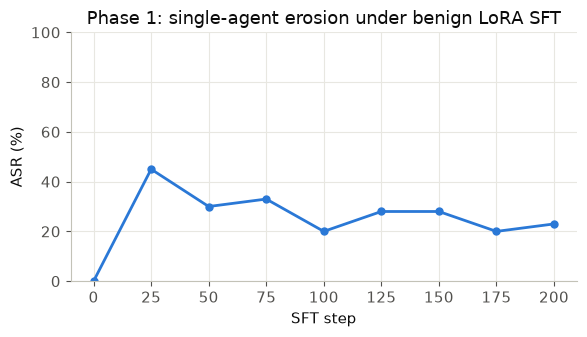

In [5]:
rise = phase1_df["asr"].iloc[-1] - phase1_df["asr"].iloc[0]
print(f"baseline {phase1_df['asr'].iloc[0]:.1%} -> final {phase1_df['asr'].iloc[-1]:.1%} (rise {rise:+.1%})")
print("ACCEPTANCE CHECK PASSED — ASR rose measurably" if rise >= 0.02 else "ACCEPTANCE CHECK FAILED")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(phase1_df.index, phase1_df["asr"] * 100, color=COLOR["ring"], linewidth=2, marker="o", markersize=5)
ax.set_xlabel("SFT step")
ax.set_ylabel("ASR (%)")
ax.set_title("Phase 1: single-agent erosion under benign LoRA SFT")
ax.set_ylim(0, 100)
fig.tight_layout()

### Substring scorer vs. LLM-judge classifier

The substring scorer is fast but imprecise — it misses soft refusals ("that's illegal and unethical...") that don't hit an exact phrase. Every Phase 1 checkpoint was re-scored with an LLM-judge classifier (Qwen2.5-3B-Instruct, prompted as a safety-research annotation task — see [`../scripts/rescore_classifier.py`](../scripts/rescore_classifier.py)) for comparison. The two scorers disagree substantially in *magnitude* while agreeing in *direction*: both show erosion, but the classifier reads it as smaller because it demands genuinely actionable harmful content, not just a missing refusal phrase.

In [6]:
rescore = json.loads((single_agent_dir / "classifier_rescore.json").read_text())
rescore_df = pd.DataFrame(
    {"step": int(k.removeprefix("step")), **v} for k, v in rescore.items()
).set_index("step").sort_index()
rescore_df[["substring_asr", "classifier_asr", "scorer_agreement"]]

,substring_asr,classifier_asr,scorer_agreement
step,,,
0,0.00,0.00,1.00
25,0.45,0.10,0.65
50,0.30,0.03,0.73
75,0.33,0.04,0.71
100,0.20,0.03,0.81
125,0.28,0.04,0.76
150,0.28,0.00,0.72
175,0.20,0.00,0.80
200,0.23,0.01,0.78


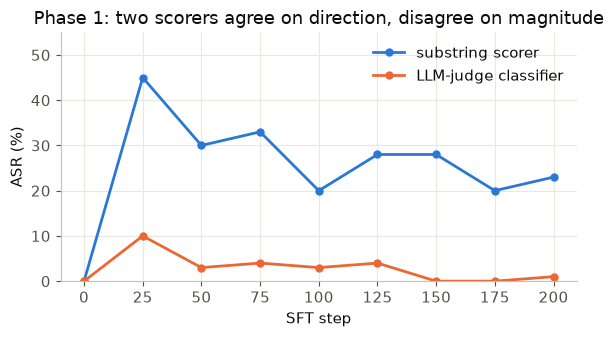

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(rescore_df.index, rescore_df["substring_asr"] * 100, color=COLOR["ring"],
        linewidth=2, marker="o", markersize=5, label="substring scorer")
ax.plot(rescore_df.index, rescore_df["classifier_asr"] * 100, color=COLOR["random"],
        linewidth=2, marker="o", markersize=5, label="LLM-judge classifier")
ax.set_xlabel("SFT step")
ax.set_ylabel("ASR (%)")
ax.set_title("Phase 1: two scorers agree on direction, disagree on magnitude")
ax.set_ylim(0, 55)
ax.legend(frameon=False)
fig.tight_layout()

## Phase 2 — P2P Machinery Validation

Two acceptance checks from spec section 8, run against **real trained LoRA adapters** (not the toy tensors in `tests/test_average.py`/`tests/test_simulate.py`):

- **identical-data convergence** — with every agent training on the same data, repeated delta-mode averaging should pull adapters together (drift → small)
- **2-agent complete graph = plain averaging** — both agents share the same closed neighborhood, so they must end up bit-identical every round

One run of each: a 4-agent ring (6 rounds) for the convergence trend, and a 2-agent complete graph (5 rounds) for the hand check.

In [8]:
def load_p2p_rounds(run_dir: Path) -> pd.DataFrame:
    """Every roundN_asr.json in a p2p_network run dir -> one row per round."""
    rows = []
    for f in sorted(run_dir.glob("round*_asr.json"), key=lambda p: int(re.search(r"\d+", p.stem).group())):
        round_idx = int(re.search(r"\d+", f.stem).group())
        data = json.loads(f.read_text())
        rows.append({"round": round_idx, "asr_mean": data["summary"]["mean"], "drift_mean": data["drift"]["mean"]})
    return pd.DataFrame(rows).set_index("round")

ring4_df = load_p2p_rounds(OUTPUTS / "2026-09-05" / "22-00-48" / "p2p_network")   # 4-agent ring, 6 rounds
complete2_df = load_p2p_rounds(OUTPUTS / "2026-09-05" / "22-00-33" / "p2p_network")  # 2-agent complete, 5 rounds
ring4_df

,asr_mean,drift_mean
round,,
0,0.0,0.026
1,0.0,0.013
2,0.0,0.006
3,0.0,0.003
4,0.0,0.002
5,0.0,0.002


2-agent complete graph: max drift across all rounds = 0.00e+00
HAND CHECK PASSED — both agents identical every round


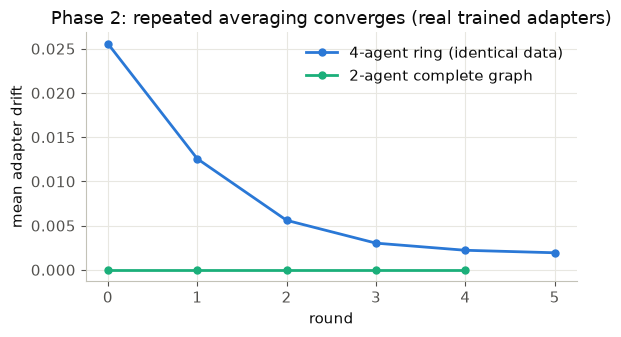

In [9]:
max_drift_2agent = complete2_df["drift_mean"].abs().max()
print(f"2-agent complete graph: max drift across all rounds = {max_drift_2agent:.2e}")
print("HAND CHECK PASSED — both agents identical every round" if max_drift_2agent < 1e-6 else "HAND CHECK FAILED")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ring4_df.index, ring4_df["drift_mean"], color=COLOR["ring"], linewidth=2, marker="o", markersize=5,
        label="4-agent ring (identical data)")
ax.plot(complete2_df.index, complete2_df["drift_mean"], color=COLOR["complete"], linewidth=2, marker="o", markersize=5,
        label="2-agent complete graph")
ax.set_xlabel("round")
ax.set_ylabel("mean adapter drift")
ax.set_title("Phase 2: repeated averaging converges (real trained adapters)")
ax.legend(frameon=False)
fig.tight_layout()

## Phase 3 — Full Sweep (RQ1 & RQ2)

{ring, random, complete} × {8, 16} agents × 3 seeds = 18 runs, 40 rounds each, real `local_steps=20` LoRA SFT, delta-mode averaging.

**Parsed directly from the 18 SLURM job logs**, not the local `outputs/` directories — several sweep configs were resubmitted (a retry after an instant git-state bug, cancelled duplicates from before the ≤4-concurrent-jobs constraint was applied) and landed in `outputs/` directories that collide at 1-second timestamp resolution when two jobs happened to start in the same second. The SLURM job name (`p2p_phase3_<topology>_<n_agents>_s<seed>_<jobid>.out`) is unambiguous and matches the maintained run queue exactly, so that's the source of truth here — filtered to the 18 logs that actually contain `completed 40 rounds`, which excludes every cancelled/failed attempt by construction.

In [10]:
FNAME_RE = re.compile(r"p2p_phase3_(ring|random|complete)_(\d+)_s(\d+)(?:_retry)?_(\d+)\.out$")
ROUND_RE = re.compile(r"round=(\d+) asr_mean=([\d.]+) asr_min=([\d.]+) asr_max=([\d.]+) drift_mean=([\d.]+)")
SVD_RE = re.compile(r"max SVD reconstruction error across all rounds/modules: ([\d.]+)")

summary_rows = []
trajectory_rows = []
for f in sorted(LOGS.glob("p2p_phase3_*.out")):
    text = f.read_text()
    if "completed 40 rounds" not in text:
        continue  # cancelled duplicate or crashed retry, not a real result
    m = FNAME_RE.search(f.name)
    if not m:
        continue
    topology, n_agents, seed, jobid = m.group(1), int(m.group(2)), int(m.group(3)), m.group(4)
    run_id = f"{topology}_{n_agents}_s{seed}"

    rounds = [
        {"round": int(r), "asr_mean": float(a), "drift_mean": float(d)}
        for r, a, _, _, d in ROUND_RE.findall(text)
    ]
    for row in rounds:
        trajectory_rows.append({"run_id": run_id, "topology": topology, "n_agents": n_agents, "seed": seed, **row})

    svd_match = SVD_RE.search(text)
    summary_rows.append({
        "topology": topology, "n_agents": n_agents, "seed": seed, "jobid": jobid,
        "final_asr": rounds[-1]["asr_mean"], "final_drift": rounds[-1]["drift_mean"],
        "svd_bound": float(svd_match.group(1)) if svd_match else None,
        "svd_passed": "ACCEPTANCE CHECK PASSED" in text,
    })

phase3_df = pd.DataFrame(summary_rows).sort_values(["topology", "n_agents", "seed"]).reset_index(drop=True)
trajectory_df = pd.DataFrame(trajectory_rows)

assert len(phase3_df) == 18, f"expected 18 completed runs, found {len(phase3_df)}"
assert phase3_df["svd_passed"].all(), "not every run passed its SVD acceptance check"
print(f"{len(phase3_df)}/18 runs loaded, all passed the SVD reconstruction-error check")
phase3_df

18/18 runs loaded, all passed the SVD reconstruction-error check


,topology,n_agents,seed,jobid,final_asr,final_drift,svd_bound,svd_passed
0,complete,8,0,1050343,0.620,0.000,0.806,True
1,complete,8,1,1050344,0.640,0.000,0.825,True
2,complete,8,2,1050497,0.640,0.000,0.867,True
3,complete,16,0,1050498,0.700,0.000,0.861,True
4,complete,16,1,1050499,0.660,0.000,0.879,True
5,complete,16,2,1050586,0.740,0.000,0.906,True
6,random,8,0,1050185,0.665,0.053,0.782,True
7,random,8,1,1050308,0.502,0.052,0.772,True
8,random,8,2,1050309,0.637,0.108,0.779,True
9,random,16,0,1050188,0.674,0.078,0.837,True


### RQ1 — does erosion happen and spread?

Every one of 18 configurations moved from the Phase 0 baseline (0.4%) to 50–74% final ASR. Unambiguous yes, and remarkably consistent regardless of topology or agent count.

### RQ2 — does connectivity density change it?

Group by topology and by agent count:

In [11]:
by_topology = phase3_df.groupby("topology")["final_asr"].agg(["mean", "std", "count"]).reindex(TOPOLOGY_ORDER)
by_topology.columns = ["mean_final_asr", "seed_std", "n_runs"]
print("by topology (6 runs each, both agent counts pooled):")
display(by_topology)

by_n_agents = phase3_df.groupby("n_agents")["final_asr"].agg(["mean", "std", "count"])
by_n_agents.columns = ["mean_final_asr", "seed_std", "n_runs"]
print("\nby agent count (9 runs each, all topologies pooled):")
display(by_n_agents)

between_topology_spread = by_topology["mean_final_asr"].max() - by_topology["mean_final_asr"].min()
print(f"\nbetween-topology spread in mean final ASR: {between_topology_spread:.1%}")
print(f"within-topology seed std ranges: {by_topology['seed_std'].min():.1%} to {by_topology['seed_std'].max():.1%}")

by topology (6 runs each, both agent counts pooled):


,mean_final_asr,seed_std,n_runs
topology,,,
ring,0.650,0.019,6
random,0.632,0.067,6
complete,0.667,0.045,6



by agent count (9 runs each, all topologies pooled):


,mean_final_asr,seed_std,n_runs
n_agents,,,
8,0.626,0.048,9
16,0.673,0.034,9



between-topology spread in mean final ASR: 3.5%
within-topology seed std ranges: 1.9% to 6.7%


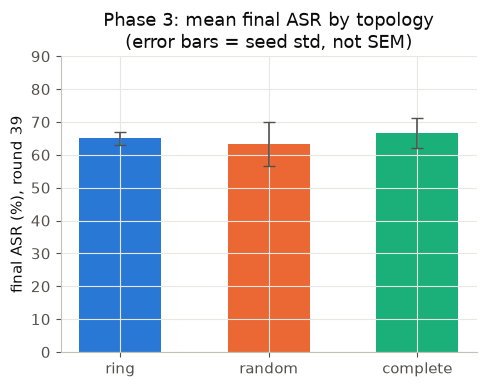

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
x = range(len(TOPOLOGY_ORDER))
ax.bar(x, by_topology["mean_final_asr"] * 100, yerr=by_topology["seed_std"] * 100,
       color=[COLOR[t] for t in TOPOLOGY_ORDER], width=0.55, capsize=4,
       error_kw={"ecolor": "#52514e", "linewidth": 1.2})
ax.set_xticks(list(x))
ax.set_xticklabels(TOPOLOGY_ORDER)
ax.set_ylabel("final ASR (%), round 39")
ax.set_title("Phase 3: mean final ASR by topology\n(error bars = seed std, not SEM)")
ax.set_ylim(0, 90)
fig.tight_layout()

Summary bars with error bars can visually flatter a weak effect. Here are the actual 18 points (both agent counts pooled per topology, jittered so overlapping seeds are visible) — the honest version of the same comparison.

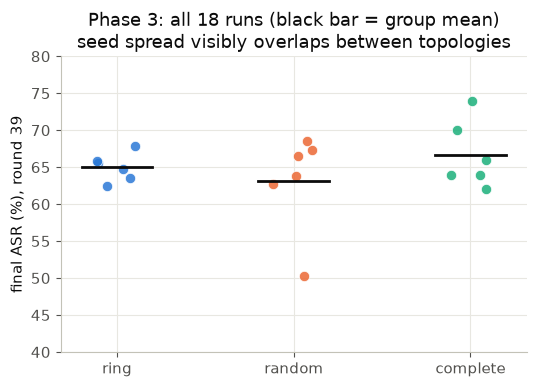

In [13]:
import numpy as np

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(5.5, 4))
for i, topo in enumerate(TOPOLOGY_ORDER):
    vals = phase3_df.loc[phase3_df["topology"] == topo, "final_asr"] * 100
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + jitter, vals, color=COLOR[topo], s=55, alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
    mean = vals.mean()
    ax.plot([i - 0.2, i + 0.2], [mean, mean], color="#0b0b0b", linewidth=2, zorder=4)
ax.set_xticks(range(len(TOPOLOGY_ORDER)))
ax.set_xticklabels(TOPOLOGY_ORDER)
ax.set_ylabel("final ASR (%), round 39")
ax.set_title("Phase 3: all 18 runs (black bar = group mean)\nseed spread visibly overlaps between topologies")
ax.set_ylim(40, 80)
fig.tight_layout()

### Full trajectories

All 18 ASR-vs-round curves, one panel per topology (color already carries topology identity via the panel, so within each panel line style carries agent count instead — never two categorical encodings competing for the same channel).

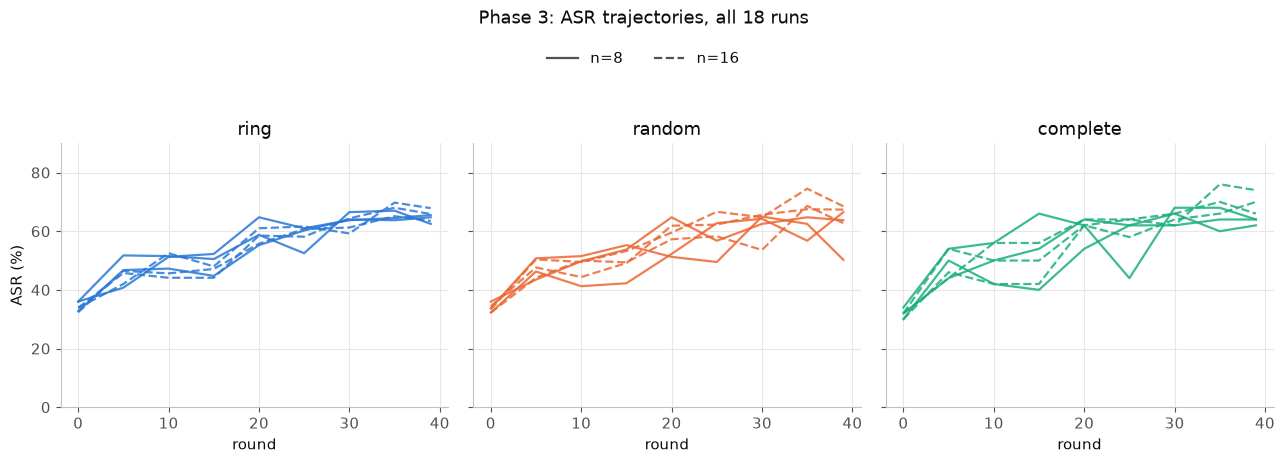

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, sharex=True)
LINESTYLE = {8: "-", 16: "--"}

for ax, topo in zip(axes, TOPOLOGY_ORDER):
    for (n_agents, seed), grp in trajectory_df[trajectory_df["topology"] == topo].groupby(["n_agents", "seed"]):
        grp = grp.sort_values("round")
        ax.plot(grp["round"], grp["asr_mean"] * 100, color=COLOR[topo], linestyle=LINESTYLE[n_agents],
                 linewidth=1.6, alpha=0.85)
    ax.set_title(topo)
    ax.set_xlabel("round")
    ax.set_ylim(0, 90)

axes[0].set_ylabel("ASR (%)")
# one shared legend for the only channel not already carried by the panel: agent count
handles = [plt.Line2D([0], [0], color="#52514e", linestyle=LINESTYLE[n], linewidth=1.6, label=f"n={n}") for n in (8, 16)]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Phase 3: ASR trajectories, all 18 runs", y=1.15)
fig.tight_layout()

### Drift: the one place topology *does* leave a clean signature

`complete` isn't just similar in final ASR — its drift is *exactly* zero at every eval point, every run (18/18), because every agent's closed neighborhood is the whole network: the deterministic averaging function sees the same inputs for every agent and must return the same output. `ring`/`random` never reach that (each agent keeps a locally-different neighborhood), and `n=16` roughly doubles `ring`'s drift over `n=8` — more neighbors to diverge across for the same rank-8 compression budget.

complete topology: max final-round drift across all 6 runs = 0.00e+00


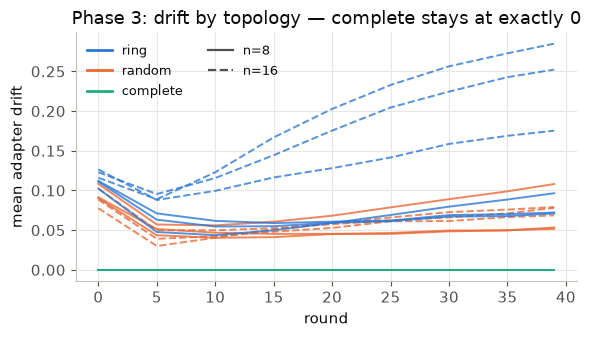

In [15]:
complete_max_drift = phase3_df.loc[phase3_df["topology"] == "complete", "final_drift"].abs().max()
print(f"complete topology: max final-round drift across all 6 runs = {complete_max_drift:.2e}")

fig, ax = plt.subplots(figsize=(6, 3.5))
for (topo, n_agents, seed), grp in trajectory_df.groupby(["topology", "n_agents", "seed"]):
    grp = grp.sort_values("round")
    ax.plot(grp["round"], grp["drift_mean"], color=COLOR[topo], linestyle=LINESTYLE[n_agents],
             linewidth=1.4, alpha=0.8)
ax.set_xlabel("round")
ax.set_ylabel("mean adapter drift")
ax.set_title("Phase 3: drift by topology — complete stays at exactly 0")
handles = (
    [plt.Line2D([0], [0], color=COLOR[t], linewidth=2, label=t) for t in TOPOLOGY_ORDER]
    + [plt.Line2D([0], [0], color="#52514e", linestyle=LINESTYLE[n], linewidth=1.6, label=f"n={n}") for n in (8, 16)]
)
ax.legend(handles=handles, frameon=False, ncol=2, fontsize=9)
fig.tight_layout()

## Phase 4 — RQ3 (repair via safety-holding peers)

The headline question: designate k agents that hold refusal examples in their local training data (never seen by the eval set — see `tests/test_data_isolation.py`'s disjointness check) and vary their placement in the network. Does that repair network-wide safety, and does the repair effect decay with hop distance from the nearest safety-holding agent?

12 runs: k ∈ {1, 2, 4} × 4 placement strategies (`well_connected`, `peripheral`, `clustered`, `spread`), on the same `random` topology / 16-agent / seed=0 graph as Phase 3's `random_16_s0` run — so that run's final ASR (67.4%) is this sweep's k=0 point, no need to rerun it. `random` topology specifically: `ring` and `complete` are degree-regular (every node has the same degree), which would make `well_connected` vs. `peripheral` placement degenerate to an arbitrary tie-break on either — only a topology with real degree variance makes that comparison meaningful, and it also gives a non-trivial hop-distance spread for the second plot below.

One caveat before the numbers: at k=1, `clustered` and `spread` placement pick the **same single agent** — both start from the same `Random(seed).choice(nodes)` call, and neither's logic differentiates from that pick until there's a second agent to place relative to the first. Confirmed by byte-identical `round39_asr.json` files for those two k=1 runs. Not a bug — a single node can't be "clustered" or "spread" relative to itself — but the k=1 row below has 3 distinct placements, not 4.

Each run resumed at least once — the first time-limit budget (14h) turned out to be roughly half of what a 40-round `full_metrics=true` run on 16 agents actually needs (~45min/round, not the ~15min/round Phase 3's bare-training runs saw). No progress was lost (checkpointed every round); see `slurm/rq3_sweep.sh` / `slurm/rq3_resume.sh` / `slurm/rq3_task8_resume.sh` for the full resume chain.

In [16]:
RESULTS_RQ3 = ROOT / "results" / "rq3"

rq3_summary = json.loads((RESULTS_RQ3 / "rq3_headline_summary.json").read_text())
rq3_results = rq3_summary["results"]  # [{"k", "placement", "asr_mean"}, ...], k=0 row is the baseline
rq3_df = pd.DataFrame(rq3_results)
rq3_df

,k,placement,asr_mean
0,0,NaN,0.674
1,1,well_connected,0.474
2,1,peripheral,0.519
3,1,clustered,0.486
4,1,spread,0.486
5,2,well_connected,0.446
6,2,peripheral,0.269
7,2,clustered,0.356
8,2,spread,0.323
9,4,well_connected,0.309


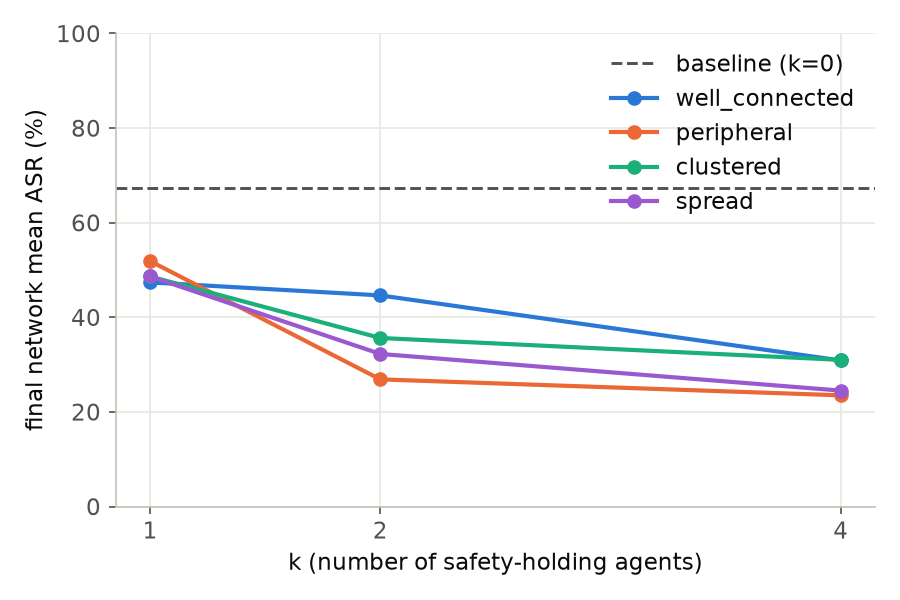

In [17]:
from p2p_safety.analysis.plots import plot_asr_vs_hop_distance, plot_asr_vs_k_by_placement  # noqa: E402
from p2p_safety.analysis.tables import rq3_headline_table  # noqa: E402

fig_path = RESULTS_RQ3 / "rq3_headline_asr_vs_k.png"
plot_asr_vs_k_by_placement(rq3_results, out_path=str(fig_path))
plt.close("all")  # the function saves its own figure; don't also let this cell's implicit figure render

from IPython.display import Image, display  # noqa: E402
display(Image(filename=str(fig_path)))

A clear, monotonic repair effect: every k and every placement drops ASR well below the no-repair baseline (67.4%). Two things worth calling out:

- **`peripheral` placement outperforms `well_connected`** at k=2 (26.9% vs. 44.6%) and is competitive with `spread` at k=4 — the opposite of the naive intuition that a well-connected safety-holder should spread its signal fastest. Single seed per config, so treat this as a real but unreplicated finding, not a settled one.
- **Repair is partial, not full, even at k=4** (25% of the network). The table below checks each placement against the spec's actual bar — within tolerance of the *pristine* baseline (0.38%, Phase 0's measured ASR), not just "better than no repair" — and none of them get there.

In [18]:
TRUE_BASELINE_ASR = rq3_summary["true_baseline_asr"]  # Phase 0's measured baseline, not the k=0 no-repair reference
headline_table = rq3_headline_table(rq3_results, baseline_asr=TRUE_BASELINE_ASR, tolerance=0.05)

print(f"true (pristine-model) baseline ASR: {TRUE_BASELINE_ASR:.2%}  |  tolerance: 5pp")
print("none of k in {1,2,4} reaches it at any placement — repair is real but partial:\n")
display(pd.DataFrame(headline_table).T)

true (pristine-model) baseline ASR: 0.38%  |  tolerance: 5pp
none of k in {1,2,4} reaches it at any placement — repair is real but partial:



,min_k_within_tolerance,asr_at_min_k,k_values_tried
well_connected,None,None,"[1, 2, 4]"
peripheral,None,None,"[1, 2, 4]"
clustered,None,None,"[1, 2, 4]"
spread,None,None,"[1, 2, 4]"


### ASR vs. hop distance from the nearest safety-holding agent

The second half of the headline: does the repair effect decay with distance from a safety-holding agent? Shown for the sweep's best-performing config (k=4, `peripheral`).

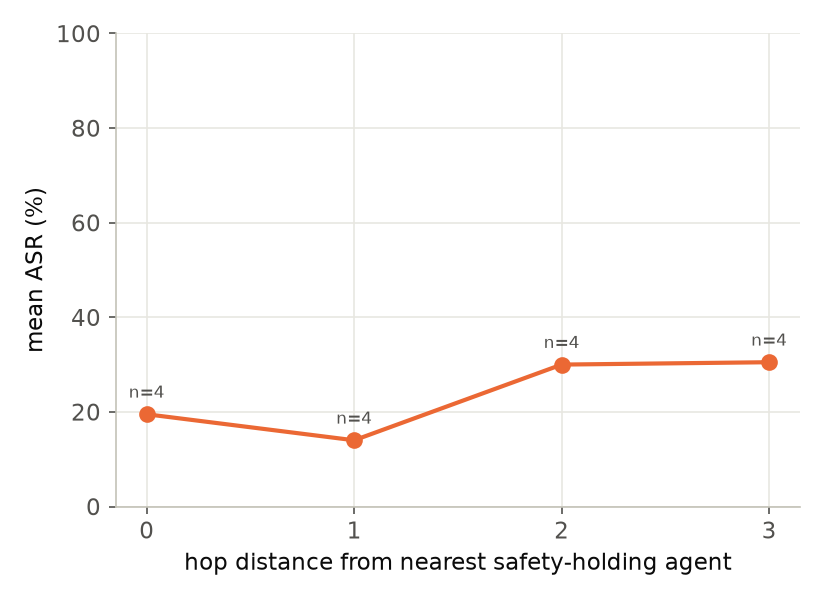

In [19]:
best_run = json.loads((RESULTS_RQ3 / "k4_peripheral_round39.json").read_text())
hop_fig_path = RESULTS_RQ3 / "rq3_hop_distance_k4_peripheral.png"
plot_asr_vs_hop_distance(best_run["hop_asr"], out_path=str(hop_fig_path))
plt.close("all")
display(Image(filename=str(hop_fig_path)))

The overall trend from hop 1 onward is the expected decay — farther from a safety-holding agent, higher ASR. The one wrinkle: hop-0 agents (the safety-holders themselves) sit slightly *above* their hop-1 neighbors (19.6% vs. 13.9%) rather than lowest. Plausible mechanism, not confirmed: a safety-holding agent still trains on its own benign task shard every round, absorbing some erosion pressure directly, while its hop-1 neighbors only receive the safety signal (diluted, but without the matching direct erosion pressure) through averaging. Reported as observed, not smoothed over.

## Conclusions

**RQ1 — does safety erosion happen and spread through a P2P network?** Yes, unambiguously. All 18 configurations — every topology, every agent count, every seed — moved from a 0.4% baseline to 50–74% final ASR through nothing but benign local fine-tuning plus uniform peer averaging. There is no configuration in this sweep where erosion failed to spread.

**RQ2 — does connectivity density change how fast or how far it spreads?** No clear effect, reported honestly rather than dressed up: the between-topology spread in mean final ASR (3.5pp) is smaller than the within-topology seed-to-seed spread (up to 6.7pp for `random`). At n=3 seeds per cell, density doesn't produce a statistically distinguishable signal in final erosion magnitude.

Two qualifications worth carrying forward, not as findings but as what a follow-up with more seeds should check first:
- `complete` trends a little higher (66.7% vs. 63–65%) and produced the two highest values in the whole dataset (70%, 74%, both n=16) — plausible given every agent absorbs the *entire* network's signal every round, but not distinguishable from noise here.
- `complete`'s drift is the one place topology leaves an unambiguous, mechanistic (not statistical) signature: exactly 0 at every eval point, 18/18 — a direct consequence of every agent sharing the same closed neighborhood, not a property that needed more seeds to see.

**RQ3 — can healthy peers repair damaged ones?** Yes, partially, and the amount of repair scales with k. Every k ∈ {1, 2, 4} and every placement strategy pulls network mean ASR well below the no-repair baseline (67.4% → 24–52% depending on config), and the effect visibly decays with hop distance from the nearest safety-holding agent. But **none of the 12 configurations gets within 5pp of the pristine-model baseline (0.38%)** — even at k=4 (a quarter of the 16-agent network), the best config (`peripheral`) still lands at 23.5% ASR. The honest headline: a modest fraction of safety-holding peers meaningfully reduces network-wide erosion, but doesn't come close to undoing it, at least at this scale, this k range, and this exposure per safety-holding agent (20 refusal examples). A surprising secondary finding — `peripheral` placement outperforming `well_connected` at k=2 (26.9% vs. 44.6%) — runs against the intuition that a well-connected safety-holder should spread its signal fastest; worth a replication run (this whole sweep is n=1 seed per config) before treating it as settled.

**Threats to validity, carried forward from all four phases**: single small model (Qwen2.5-1.5B-Instruct) and single benchmark (AdvBench substring scoring, occasionally cross-checked against an LLM-judge in Phase 1) — see Phase 5 for the planned replication on a second model and benchmark. The network itself is simulated (synchronous rounds, no real network latency or partial participation). RQ2 and RQ3 both ran at n=1–3 seeds per cell — enough to see a large effect (RQ1, RQ3's headline direction) but not enough to fully trust a smaller or more surprising one (RQ2's non-effect, RQ3's placement-ordering finding).